In [4]:
from google.colab import files

uploaded = files.upload()

Saving Online Retail.xlsx to Online Retail (1).xlsx


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_excel("Online Retail.xlsx")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [6]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [7]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

Dataset Shape: (541909, 8)

Column Names:
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [9]:
print("\nMissing Values:")
print(df.isnull().sum())

print("\nMissing Value Percentage:")
print((df.isnull().sum() / len(df) * 100).round(2))


Missing Values:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

Missing Value Percentage:
InvoiceNo       0.00
StockCode       0.00
Description     0.27
Quantity        0.00
InvoiceDate     0.00
UnitPrice       0.00
CustomerID     24.93
Country         0.00
dtype: float64


In [10]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 5268


In [11]:
df = df.drop_duplicates()

print("New Dataset Shape:", df.shape)
print("Remaining Duplicate Rows:", df.duplicated().sum())

New Dataset Shape: (536641, 8)
Remaining Duplicate Rows: 0


In [12]:
print("Negative Quantity Rows:", (df["Quantity"] < 0).sum())

print("Zero Quantity Rows:", (df["Quantity"] == 0).sum())

print("Negative or Zero Unit Price Rows:", (df["UnitPrice"] <= 0).sum())

Negative Quantity Rows: 10587
Zero Quantity Rows: 0
Negative or Zero Unit Price Rows: 2512


In [13]:
print("Sample Negative Quantity Records:")
display(df[df["Quantity"] < 0].head())

print("\nSample Zero/Negative Unit Price Records:")
display(df[df["UnitPrice"] <= 0].head())

Sample Negative Quantity Records:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom



Sample Zero/Negative Unit Price Records:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.0,NaN,United Kingdom
1970,536545,21134,NaN,1,2010-12-01 14:32:00,0.0,NaN,United Kingdom
1971,536546,22145,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1972,536547,37509,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1987,536549,85226A,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom


In [14]:
print(
    "Invoice numbers starting with C:",
    df["InvoiceNo"].astype(str).str.startswith("C").sum()
)

Invoice numbers starting with C: 9251


In [16]:
df_clean = df[
    (df["Quantity"] > 0) &
    (df["UnitPrice"] > 0)
].copy()

print("Original dataset shape:", df.shape)
print("Cleaned dataset shape:", df_clean.shape)

print("\nNegative Quantity Rows Remaining:",
      (df_clean["Quantity"] < 0).sum())

print("Zero or Negative Unit Price Rows Remaining:",
      (df_clean["UnitPrice"] <= 0).sum())

Original dataset shape: (536641, 8)
Cleaned dataset shape: (524878, 8)

Negative Quantity Rows Remaining: 0
Zero or Negative Unit Price Rows Remaining: 0


In [17]:
print("Missing Values in Cleaned Dataset:")
print(df_clean.isnull().sum())

print("\nMissing Value Percentage:")
print((df_clean.isnull().sum() / len(df_clean) * 100).round(2))

Missing Values in Cleaned Dataset:
InvoiceNo           0
StockCode           0
Description         0
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     132186
Country             0
dtype: int64

Missing Value Percentage:
InvoiceNo       0.00
StockCode       0.00
Description     0.00
Quantity        0.00
InvoiceDate     0.00
UnitPrice       0.00
CustomerID     25.18
Country         0.00
dtype: float64


In [18]:
print("Number of Unique Products:", df_clean["StockCode"].nunique())

print("Number of Unique Product Descriptions:",
      df_clean["Description"].nunique())

print("Number of Countries:",
      df_clean["Country"].nunique())

Number of Unique Products: 3922
Number of Unique Product Descriptions: 4026
Number of Countries: 38


In [19]:
df_clean["Revenue"] = (
    df_clean["Quantity"] * df_clean["UnitPrice"]
)

print(df_clean[[
    "Description",
    "Quantity",
    "UnitPrice",
    "Revenue"
]].head())

                           Description  Quantity  UnitPrice  Revenue
0   WHITE HANGING HEART T-LIGHT HOLDER         6       2.55    15.30
1                  WHITE METAL LANTERN         6       3.39    20.34
2       CREAM CUPID HEARTS COAT HANGER         8       2.75    22.00
3  KNITTED UNION FLAG HOT WATER BOTTLE         6       3.39    20.34
4       RED WOOLLY HOTTIE WHITE HEART.         6       3.39    20.34


In [20]:
print(
    "Total Revenue:",
    round(df_clean["Revenue"].sum(), 2)
)

Total Revenue: 10642110.8


In [21]:
top_quantity = (
    df_clean.groupby("Description")["Quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_quantity)

Description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        78033
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54951
JUMBO BAG RED RETROSPOT               48371
WHITE HANGING HEART T-LIGHT HOLDER    37872
POPCORN HOLDER                        36749
PACK OF 72 RETROSPOT CAKE CASES       36396
ASSORTED COLOUR BIRD ORNAMENT         36362
RABBIT NIGHT LIGHT                    30739
MINI PAINT SET VINTAGE                26633
Name: Quantity, dtype: int64


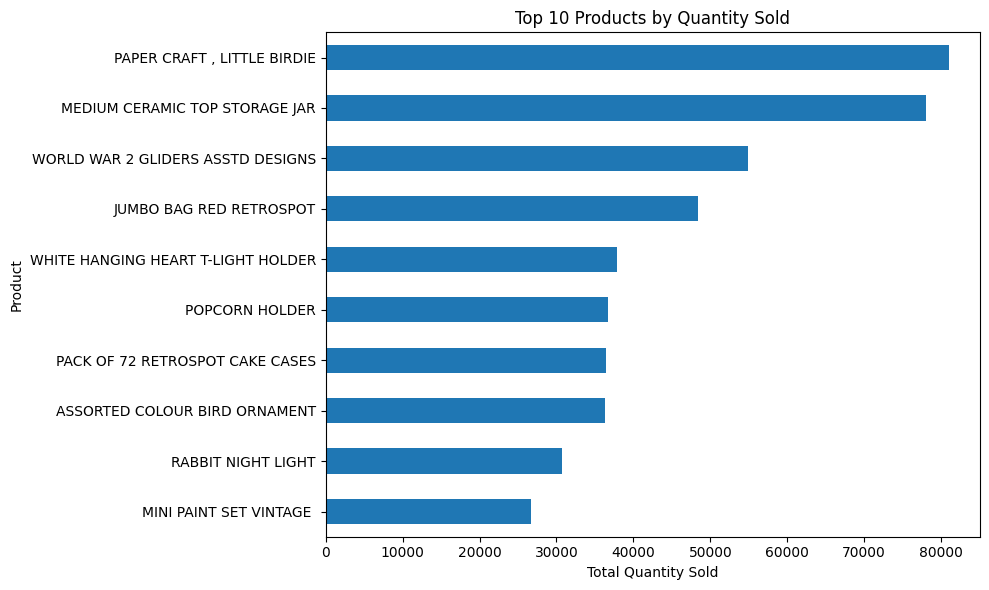

In [22]:
plt.figure(figsize=(10, 6))

top_quantity.sort_values().plot(kind="barh")

plt.xlabel("Total Quantity Sold")
plt.ylabel("Product")
plt.title("Top 10 Products by Quantity Sold")

plt.tight_layout()
plt.show()

In [23]:
top_revenue = (
    df_clean.groupby("Description")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_revenue)

Description
DOTCOM POSTAGE                        206248.77
REGENCY CAKESTAND 3 TIER              174156.54
PAPER CRAFT , LITTLE BIRDIE           168469.60
WHITE HANGING HEART T-LIGHT HOLDER    106236.72
PARTY BUNTING                          99445.23
JUMBO BAG RED RETROSPOT                94159.81
MEDIUM CERAMIC TOP STORAGE JAR         81700.92
POSTAGE                                78101.88
Manual                                 77752.82
RABBIT NIGHT LIGHT                     66870.03
Name: Revenue, dtype: float64


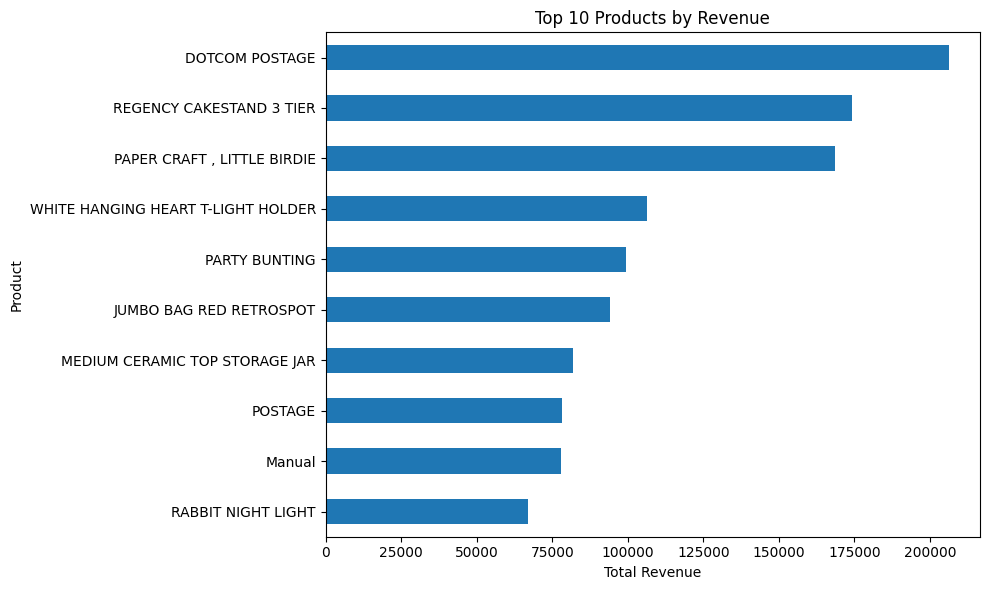

In [24]:
plt.figure(figsize=(10, 6))

top_revenue.sort_values().plot(kind="barh")

plt.xlabel("Total Revenue")
plt.ylabel("Product")
plt.title("Top 10 Products by Revenue")

plt.tight_layout()
plt.show()

In [25]:
country_revenue = (
    df_clean.groupby("Country")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(country_revenue)

Country
United Kingdom    9001744.094
Netherlands        285446.340
EIRE               283140.520
Germany            228678.400
France             209625.370
Australia          138453.810
Spain               61558.560
Switzerland         57067.600
Belgium             41196.340
Sweden              38367.830
Name: Revenue, dtype: float64


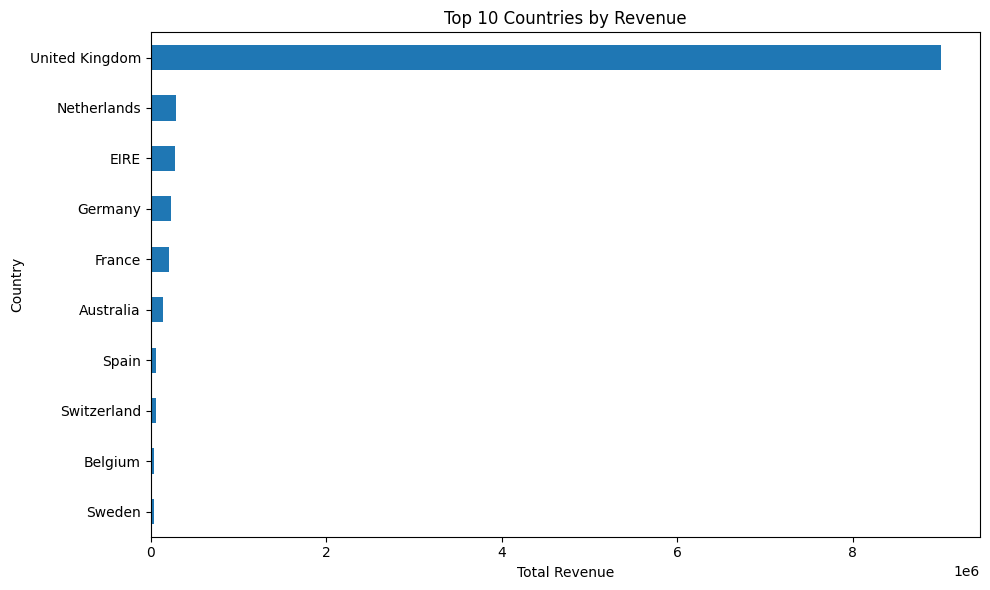

In [26]:
plt.figure(figsize=(10, 6))

country_revenue.sort_values().plot(kind="barh")

plt.xlabel("Total Revenue")
plt.ylabel("Country")
plt.title("Top 10 Countries by Revenue")

plt.tight_layout()
plt.show()

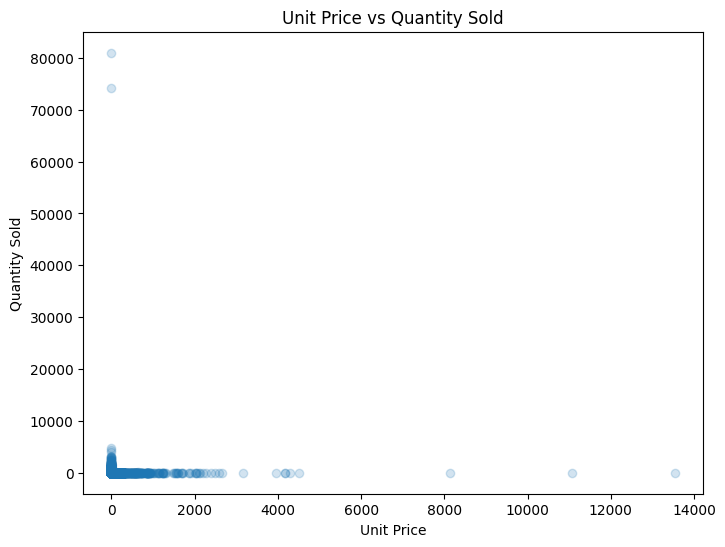

In [27]:
plt.figure(figsize=(8, 6))

plt.scatter(
    df_clean["UnitPrice"],
    df_clean["Quantity"],
    alpha=0.2
)

plt.xlabel("Unit Price")
plt.ylabel("Quantity Sold")
plt.title("Unit Price vs Quantity Sold")

plt.show()

In [28]:
print(
    "Correlation between Unit Price and Quantity:",
    df_clean["UnitPrice"].corr(df_clean["Quantity"])
)

Correlation between Unit Price and Quantity: -0.0037884185655402336
